# Notebook for constructing age models for Michipicoten Island Formation

In [10]:
using Pkg
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

plot_posterior_paths (generic function with 1 method)

## Michipicoten Island Formation

- We define the bottom of the section to be the base of the Quebect Harbor andesite which is above the West Sand Bay tuff
- We define the top of the section to be the Davieaux Island rhyolite

In [11]:
Michipicoten_Name = ("West Sand Bay Member tuff", "Davieaux Island rhyolite") # Et cetera
Michipicoten_Age           = [ 1084.35, 1083.52] # Measured ages
Michipicoten_Age_sigma     = [ 0.2/2,   0.23/2] # Measured 1-σ uncertainties
Michipicoten_Height        = [ 0,     1006] # Depths below surface should be negative
Michipicoten_Age_Sidedness = [0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Michipicoten_Path = "../code_output/age_models/Michipicoten" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Michipicoten_section = make_ChronAgeData(Michipicoten_Name, Michipicoten_Age, Michipicoten_Age_sigma, Michipicoten_Height, Michipicoten_Age_Sidedness, Michipicoten_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{2}(("West Sand Bay Member tuff", "Davieaux Island rhyolite"), [0.0, 1006.0], [0.01, 0.01], [1084.35, 1083.52], [0.1, 0.115], [NaN, NaN], [NaN, NaN], [NaN, NaN], [NaN, NaN], [0.0, 0.0], [0.0, 0.0], [#undef, #undef], (:Chronometer, :Chronometer), [NaN NaN; NaN NaN; … ; NaN NaN; NaN NaN], "../code_output/age_models/Michipicoten", 2, "Ma", "m", :cdf)

In [12]:
Michipicoten_age_model_config, Michipicoten_age_model_mdl, Michipicoten_age_model_agedist, Michipicoten_age_model_lldist = run_age_model(Michipicoten_section, 2, 0.2, 5000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:28
┌ Info: Burn-in: 3530000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:01
┌ Info: Collecting sieved stationary distribution: 3530000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:01


(StratAgeModelConfiguration(2.0, 3530000, 5000, 706, 0.2), StratAgeModel([0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0  …  988.0, 990.0, 992.0, 994.0, 996.0, 998.0, 1000.0, 1002.0, 1004.0, 1006.0], [1084.3597445720459, 1084.3579121495902, 1084.3559711672976, 1084.353601226862, 1084.3521038185158, 1084.350405599533, 1084.3487758129068, 1084.3468460745887, 1084.345231507105, 1084.3435220014446  …  1083.5224496046699, 1083.5205476663054, 1083.5186435758199, 1083.5170858350984, 1083.5154035338103, 1083.5134325914555, 1083.511652870894, 1083.5099721113563, 1083.5077703344507, 1083.5061715906963], [0.0826882440343621, 0.08395546989950589, 0.08510905973195995, 0.08746554398168994, 0.08857792025175368, 0.08959071560404647, 0.09055163158469205, 0.09166324667346404, 0.0927692449754972, 0.09355881631617  …  0.10193438281338021, 0.10087260324510099, 0.09959610582042569, 0.0985198348920906, 0.09705782138212242, 0.09536637879883651, 0.09418090535787627, 0.09350062884076607, 0.09169427008512

### posterior summary age model

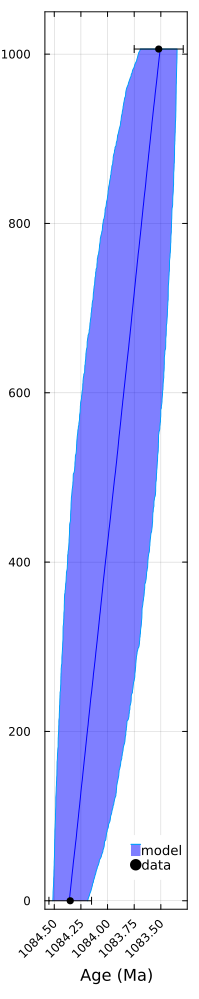

In [25]:
Michipicoten_age_model = plot_age_model(Michipicoten_section, Michipicoten_age_model_mdl, save_figure=false)
plot!(ylim=(-10, 1050))
# show xticks 
yticks!([0, 200, 400, 600, 800, 1000])
savefig(Michipicoten_age_model, Michipicoten_section.Path*"_AgeDepthModel.pdf")
display(Michipicoten_age_model)

### example posterior accumulation models

In [14]:
plot_accumulation_model(Michipicoten_section, Michipicoten_age_model_config, Michipicoten_age_model_mdl, Michipicoten_age_model_agedist, save_figure=false)

ArgumentError: ArgumentError: invalid Array dimensions

### example posterior age models

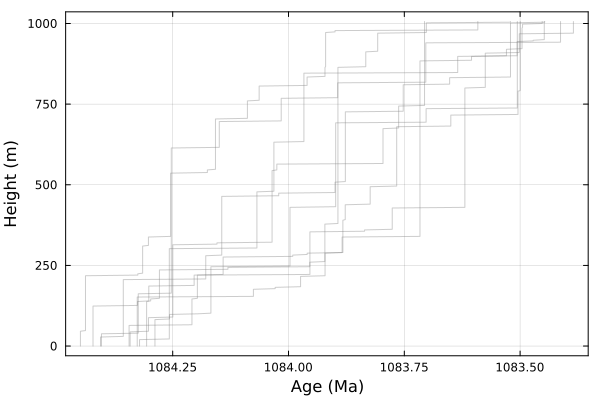

In [15]:
plot_posterior_paths(Michipicoten_section, Michipicoten_age_model_agedist, Michipicoten_age_model_mdl)

## save the age models to a file

In [16]:
Michipicoten_age_model_agedist

504×5000 Matrix{Float64}:
 1084.32  1084.44  1084.37  1084.26  …  1084.37  1084.43  1084.47  1084.37
 1084.32  1084.44  1084.37  1084.26     1084.37  1084.43  1084.47  1084.37
 1084.32  1084.44  1084.37  1084.26     1084.37  1084.43  1084.47  1084.37
 1084.32  1084.44  1084.37  1084.26     1084.37  1084.43  1084.47  1084.37
 1084.32  1084.44  1084.37  1084.26     1084.19  1084.43  1084.47  1084.37
 1084.32  1084.44  1084.37  1084.26  …  1084.19  1084.43  1084.47  1084.37
 1084.32  1084.44  1084.37  1084.26     1084.19  1084.43  1084.47  1084.37
 1084.32  1084.44  1084.37  1084.26     1084.19  1084.43  1084.47  1084.37
 1084.29  1084.44  1084.37  1084.26     1084.19  1084.43  1084.47  1084.37
 1084.29  1084.44  1084.37  1084.26     1084.19  1084.43  1084.47  1084.37
    ⋮                                ⋱                             
 1083.44  1083.5   1083.49  1083.55  …  1083.43  1083.5   1083.54  1083.61
 1083.44  1083.5   1083.49  1083.55     1083.43  1083.5   1083.54  1083.61
 1083.

In [17]:
# use the mdl.height as index, agedist as the data
Michipicoten_age_models_df = DataFrame(hcat(Michipicoten_age_model_mdl.Height, Michipicoten_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Michipicoten_age_models_df, Dict(:x1 => "height"))
Michipicoten_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1084.32,1084.44,1084.37,1084.26,1084.32,1084.09,1084.34,1084.37,1084.36,1084.48,1084.27,1084.37,1084.32,1084.2,1084.25,1084.5,1084.33,1084.47,1084.29,1084.19,1084.31,1084.4,1084.16,1084.36,1084.3,1084.48,1084.48,1084.39,1084.25,1084.39,1084.44,1084.35,1084.37,1084.37,1084.38,1084.41,1084.39,1084.36,1084.28,1084.37,1084.49,1084.34,1084.42,1084.4,1084.34,1084.44,1084.31,1084.24,1084.51,1084.5,1084.32,1084.32,1084.33,1084.31,1084.37,1084.3,1084.49,1084.28,1084.18,1084.44,1084.41,1084.3,1084.28,1084.36,1084.3,1084.49,1084.32,1084.37,1084.43,1084.34,1084.28,1084.37,1084.33,1084.26,1084.27,1084.25,1084.27,1084.39,1084.19,1084.26,1084.41,1084.38,1084.29,1084.41,1084.19,1084.31,1084.33,1084.37,1084.51,1084.33,1084.3,1084.37,1084.42,1084.32,1084.4,1084.33,1084.42,1084.45,1084.36,⋯
2,2.0,1084.32,1084.44,1084.37,1084.26,1084.32,1084.09,1084.34,1084.37,1084.36,1084.48,1084.27,1084.37,1084.23,1084.2,1084.25,1084.5,1084.33,1084.47,1084.29,1084.19,1084.31,1084.4,1084.16,1084.36,1084.3,1084.48,1084.48,1084.39,1084.25,1084.39,1084.44,1084.35,1084.37,1084.37,1084.38,1084.41,1084.39,1084.36,1084.28,1084.37,1084.49,1084.34,1084.42,1084.4,1084.34,1084.44,1084.31,1084.24,1084.51,1084.5,1084.32,1084.32,1084.33,1084.31,1084.37,1084.3,1084.49,1084.28,1084.18,1084.44,1084.41,1084.3,1084.28,1084.36,1084.3,1084.49,1084.32,1084.37,1084.43,1084.34,1084.28,1084.37,1084.33,1084.26,1084.27,1084.25,1084.27,1084.39,1084.19,1084.26,1084.41,1084.38,1084.29,1084.41,1084.19,1084.31,1084.33,1084.37,1084.51,1084.33,1084.3,1084.37,1084.42,1084.32,1084.4,1084.33,1084.42,1084.45,1084.36,⋯
3,4.0,1084.32,1084.44,1084.37,1084.26,1084.32,1084.09,1084.34,1084.37,1084.36,1084.48,1084.27,1084.37,1084.23,1084.15,1084.25,1084.5,1084.33,1084.47,1084.29,1084.19,1084.31,1084.4,1084.16,1084.36,1084.3,1084.48,1084.48,1084.39,1084.25,1084.39,1084.44,1084.35,1084.37,1084.37,1084.38,1084.41,1084.39,1084.36,1084.28,1084.37,1084.49,1084.34,1084.29,1084.4,1084.34,1084.44,1084.31,1084.24,1084.51,1084.5,1084.32,1084.32,1084.33,1084.31,1084.37,1084.3,1084.49,1084.28,1084.18,1084.44,1084.41,1084.3,1084.28,1084.36,1084.3,1084.49,1084.31,1084.37,1084.43,1084.34,1084.28,1084.37,1084.33,1084.26,1084.27,1084.25,1084.27,1084.39,1084.19,1084.26,1084.41,1084.38,1084.29,1084.41,1084.19,1084.31,1084.33,1084.37,1084.51,1084.33,1084.3,1084.37,1084.42,1084.32,1084.4,1084.32,1084.42,1084.45,1084.36,⋯
4,6.0,1084.32,1084.44,1084.37,1084.26,1084.32,1084.09,1084.34,1084.37,1084.36,1084.48,1084.27,1084.37,1084.23,1084.15,1084.25,1084.5,1084.33,1084.47,1084.29,1084.19,1084.31,1084.4,1084.16,1084.36,1084.3,1084.48,1084.48,1084.39,1084.25,1084.39,1084.44,1084.35,1084.36,1084.37,1084.38,1084.41,1084.39,1084.36,1084.28,1084.37,1084.49,1084.34,1084.29,1084.4,1084.34,1084.44,1084.31,1084.24,1084.51,1084.5,1084.32,1084.32,1084.33,10

In [18]:
# write the DataFrame to a csv file
CSV.write(Michipicoten_section.Path*"_posterior_ages.csv", Michipicoten_age_models_df)

"../code_output/age_models/Michipicoten_posterior_ages.csv"